In [6]:
from dataclasses import dataclass

import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

from core.fullstate import fullstate
from core.time_evol_solver import create_time_evol_solver
from model.axis import Axis
from model.physical_system import TotalMagnetizationObservable, SingleNVSystem
from service.compute_time_evol import get_compute_time_evol_state_series_service

In [19]:
class NVSensor:
    @classmethod
    def _create_solver(self):
        system = SingleNVSystem(
            h=1.0,
            axis=Axis.Y,
        )
    
        solver = create_time_evol_solver(
            system=system,
            observable=TotalMagnetizationObservable(
                n_qubit=1,
                axis=Axis.X,
            ),
            init_psi=fullstate("z+"),
        )

        return solver
    
    def __init__(self):
        pass

    def measure_and_get_expect(self, *, t_begin, t_end, u_t):
        solver = self._create_solver()

        t_arr = np.linspace(t_begin, t_end, 21)
    
        valid_time_mask, state_series = get_compute_time_evol_state_series_service().execute(
            solver=solver,
            n_mpx=1,
            u_t=u_t,
            t_arr=t_arr,
            reset_state=True,
            full_span=True,
        )

        return state_series[-1, 0]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 1461.65it/s]


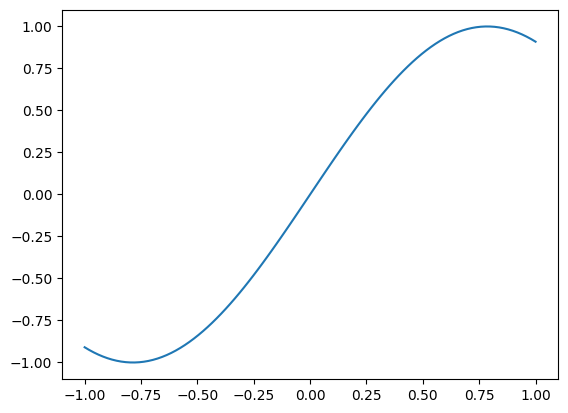

In [20]:
def _test():
    sensor = NVSensor()
    
    b_arr = np.linspace(-1, 1, 100)
    e_arr = []
    for b in tqdm(b_arr):
        e = sensor.measure_and_get_expect(t_begin=0, t_end=1, u_t=lambda t: b)
        e_arr.append(e)
    e_arr = np.array(e_arr)
    plt.plot(b_arr, e_arr)

_test()